In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


In [4]:
import pandas as pd

# Define the exact path based on your Kaggle file structure
path = "/kaggle/input/datasets/olistbr/brazilian-ecommerce/"

print("Loading datasets...")
# 1. Load all 9 CSV files
customers = pd.read_csv(path + "olist_customers_dataset.csv")
sellers = pd.read_csv(path + "olist_sellers_dataset.csv")
reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")
geolocation = pd.read_csv(path + "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(
    path + "product_category_name_translation.csv"
)
orders = pd.read_csv(path + "olist_orders_dataset.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")

print("Merging datasets...")

# 2. Start with orders and merge customers
df_master = pd.merge(orders, customers, on="customer_id", how="left")

# 3. Merge with order items (using 'order_id')
df_master = pd.merge(df_master, order_items, on="order_id", how="left")

# 4. Merge with products (using 'product_id')
df_master = pd.merge(df_master, products, on="product_id", how="left")

# 5. Translate Portuguese category names to English
df_master = pd.merge(
    df_master, category_translation, on="product_category_name", how="left"
)

# 6. Merge with sellers (using 'seller_id')
df_master = pd.merge(df_master, sellers, on="seller_id", how="left")

# 7. Aggregate and merge payments (since an order can have multiple payment installments)
payments_agg = (
    payments.groupby("order_id")
    .agg(
        total_payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_type=("payment_type", "first"),
    )
    .reset_index()
)
df_master = pd.merge(df_master, payments_agg, on="order_id", how="left")

# 8. Aggregate and merge reviews (taking the average score or latest review per order if multiple exist)
reviews_agg = (
    reviews.groupby("order_id")
    .agg(review_score=("review_score", "mean"))
    .reset_index()
)
df_master = pd.merge(df_master, reviews_agg, on="order_id", how="left")

print("Merging complete!")
print(f"Master DataFrame shape: {df_master.shape}")
display(df_master.head(3))

Loading datasets...
Merging datasets...
Merging complete!
Master DataFrame shape: (113425, 34)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,total_payment_value,payment_installments,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.0,13.0,housewares,9350.0,maua,SP,38.71,1.0,credit_card,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,13.0,19.0,perfumery,31570.0,belo horizonte,SP,141.46,1.0,boleto,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.0,21.0,auto,14840.0,guariba,SP,179.12,3.0,credit_card,5.0


In [5]:
df_master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,total_payment_value,payment_installments,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.0,13.0,housewares,9350.0,maua,SP,38.71,1.0,credit_card,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,13.0,19.0,perfumery,31570.0,belo horizonte,SP,141.46,1.0,boleto,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.0,21.0,auto,14840.0,guariba,SP,179.12,3.0,credit_card,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,10.0,20.0,pet_shop,31842.0,belo horizonte,MG,72.20,1.0,credit_card,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,15.0,15.0,stationery,8752.0,mogi das cruzes,SP,28.62,1.0,credit_card,5.0


In [6]:
df_master.shape

(113425, 34)

In [7]:
df_master.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
product_category_name            2378
product_name_lenght              2378
product_description_lenght       2378
product_photos_qty               2378
product_weight_g                  793
product_length_cm                 793
product_height_cm                 793
product_width_cm                  793
product_cate

In [8]:
df_master=df_master.dropna(subset=['order_item_id','product_id','seller_id',
                                   'shipping_limit_date','price','freight_value',
                                   'seller_zip_code_prefix','seller_city','seller_state',
                                  'total_payment_value'])

In [9]:
df_master.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name            1603
product_name_lenght              1603
product_description_lenght       1603
product_photos_qty               1603
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
product_cate

I will keep nulls in review score because pandas can skip Nan when make calculation and to make real analysis dont make fill 

In [10]:
df_master['product_category_name_english']=df_master['product_category_name_english'].fillna("UnKnown")
df_master['product_category_name']=df_master['product_category_name'].fillna("UnKnown")

In [11]:
df_master.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
product_name_lenght              1603
product_description_lenght       1603
product_photos_qty               1603
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
product_cate

In [12]:
df_master['product_name_lenght'] = df_master['product_name_lenght'].fillna(0)
df_master['product_description_lenght'] = df_master['product_description_lenght'].fillna(0)
df_master['product_photos_qty'] = df_master['product_photos_qty'].fillna(0)

In [13]:
df_master.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
product_cate

In [14]:
dim_cols=['product_weight_g','product_length_cm','product_height_cm','product_width_cm']
for col in dim_cols:
   df_master[col]=df_master[col].fillna(df_master[col].median())

In [15]:
df_master.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [16]:
# Check the order status of rows where the delivery date is missing
missing_delivery = df_master[df_master['order_delivered_customer_date'].isna()]
print(missing_delivery['order_status'].value_counts())

order_status
shipped        1185
canceled        535
invoiced        359
processing      357
delivered         8
unavailable       7
approved          3
Name: count, dtype: int64


unavailable means product is out of stock


In [17]:
# Create a condition to find ONLY the glitched rows
glitched_delivered = (df_master['order_status'] == 'delivered') & (
    df_master['order_delivered_customer_date'].isna()
)

# Keep everything EXCEPT (~) those 8 rows
df_master = df_master[~glitched_delivered]

In [18]:
df_master.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1193
order_delivered_customer_date    2446
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [19]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112639 entries, 0 to 113424
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112639 non-null  object 
 1   customer_id                    112639 non-null  object 
 2   order_status                   112639 non-null  object 
 3   order_purchase_timestamp       112639 non-null  object 
 4   order_approved_at              112624 non-null  object 
 5   order_delivered_carrier_date   111446 non-null  object 
 6   order_delivered_customer_date  110193 non-null  object 
 7   order_estimated_delivery_date  112639 non-null  object 
 8   customer_unique_id             112639 non-null  object 
 9   customer_zip_code_prefix       112639 non-null  int64  
 10  customer_city                  112639 non-null  object 
 11  customer_state                 112639 non-null  object 
 12  order_item_id                  1126

In [20]:
df_master.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,total_payment_value,payment_installments,review_score
count,112639.000000,112639.000000,112639.000000,112639.000000,112639.000000,112639.000000,112639.000000,112639.000000,112639.000000,112639.000000,112639.000000,112639.000000,112639.000000,112639.000000,111697.000000
mean,35120.716599,1.197827,120.653233,19.991045,48.082778,776.632419,2.178304,2093.485516,30.153233,16.592965,22.995916,24438.257611,180.281748,3.018404,4.033176
std,29866.407986,0.705132,183.641081,15.806840,11.508673,654.185314,1.729083,3751.459855,16.152343,13.442658,11.706028,27595.483164,272.857862,2.802622,1.386047
min,1003.000000,1.000000,0.850000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,9.590000,0.000000,1.000000
25%,11310.000000,1.000000,39.900000,13.080000,42.000000,341.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,65.670000,1.000000,4.000000
50%,24340.000000,1.000000,74.990000,16.260000,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13568.000000,114.440000,2.000000,5.000000
75%,59030.000000,1.000000,134.900000,21.150000,57.000000,981.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,27930.000000,195.390000,4.000000,5.000000
max,99990.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,13664.080000,24.000000,5.000000


In [21]:
df_master.duplicated().sum()

np.int64(0)

In [174]:
customer_orders = df_master.groupby('customer_unique_id')['order_id'].nunique()
repeat_rate = (customer_orders > 1).mean()
print(f"Repeat customer rate: {repeat_rate*100:.2f}%")
print(customer_orders.value_counts().sort_index().head(10))

Repeat customer rate: 3.05%
order_id
1     92498
2      2673
3       192
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64


{'whiskers': [<matplotlib.lines.Line2D at 0x79290fe39f10>,
 'caps': [<matplotlib.lines.Line2D at 0x79290fe3a570>,
 'boxes': [<matplotlib.lines.Line2D at 0x79290fe39c70>],
 'medians': [<matplotlib.lines.Line2D at 0x79290fe3abd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x79290fe3ae40>],
 'means': []}

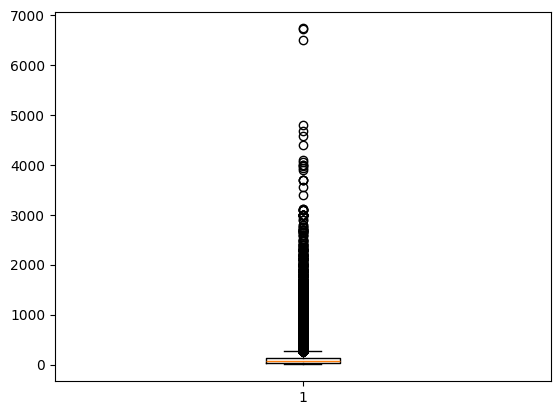

In [22]:
import matplotlib.pyplot as plt
plt.boxplot(df_master['price'])


In [23]:
df_master.to_csv('cleaned_olist_master.csv', index=False)


In [24]:
df_master.nunique()

order_id                         98657
customer_id                      98657
order_status                         7
order_purchase_timestamp         98103
order_approved_at                90166
order_delivered_carrier_date     81016
order_delivered_customer_date    95663
order_estimated_delivery_date      449
customer_unique_id               95411
customer_zip_code_prefix         14976
customer_city                     4110
customer_state                      27
order_item_id                       21
product_id                       32949
seller_id                         3095
shipping_limit_date              93309
price                             5968
freight_value                     6999
product_category_name               74
product_name_lenght                 67
product_description_lenght        2961
product_photos_qty                  20
product_weight_g                  2204
product_length_cm                   99
product_height_cm                  102
product_width_cm         

In [25]:
top_categories=(df_master.groupby("product_category_name_english")['price'].sum()
                          .sort_values(ascending=False).head(15))
top_categories

product_category_name_english
health_beauty            1258546.37
watches_gifts            1204727.68
bed_bath_table           1036988.68
sports_leisure            987869.97
computers_accessories     911843.33
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592602.81
garden_tools              485256.46
toys                      483757.61
baby                      411764.89
perfumery                 399124.87
telephony                 323667.53
office_furniture          273960.70
Name: price, dtype: float64

<Axes: ylabel='product_category_name_english'>

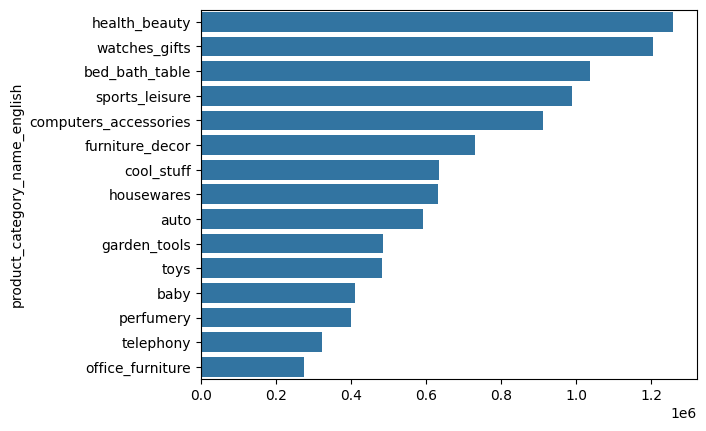

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(x=top_categories.values,y=top_categories.index)

<Axes: xlabel='order_purchase_timestamp', ylabel='order_id'>

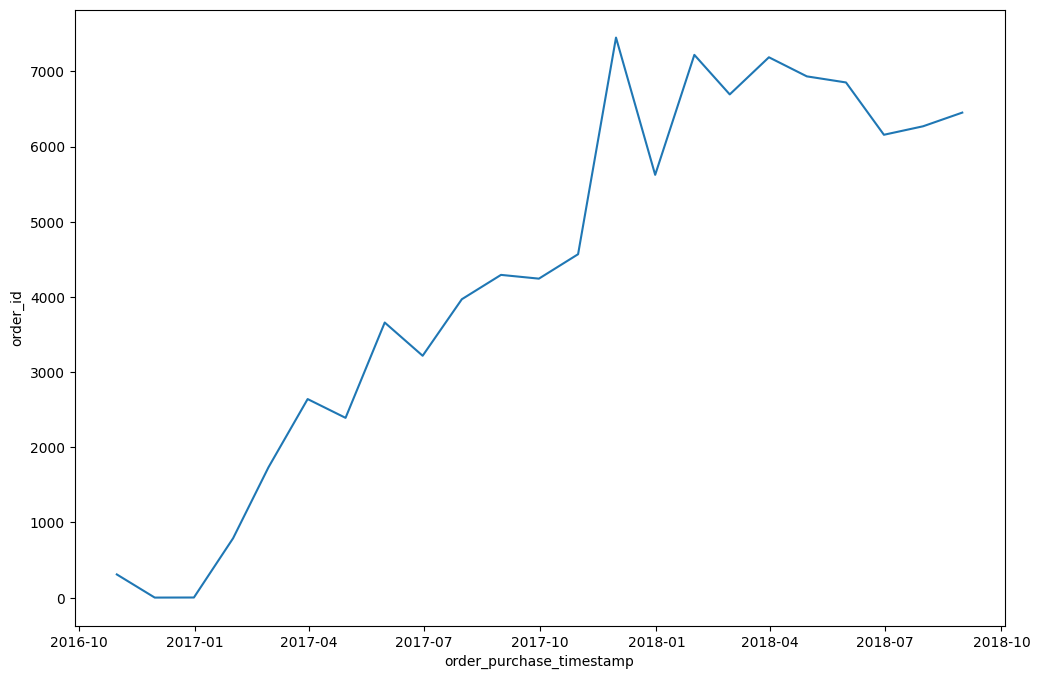

In [138]:
df_master['order_purchase_timestamp']=pd.to_datetime(df_master['order_purchase_timestamp'])
monthly_orders = (
    df_master.set_index("order_purchase_timestamp")
    .resample("ME")["order_id"]
    .nunique()
)
monthly_orders = monthly_orders.loc["2016-10":"2018-08"]
plt.figure(figsize=(12,8))
sns.lineplot(data=monthly_orders ) 

<Axes: ylabel='order_status'>

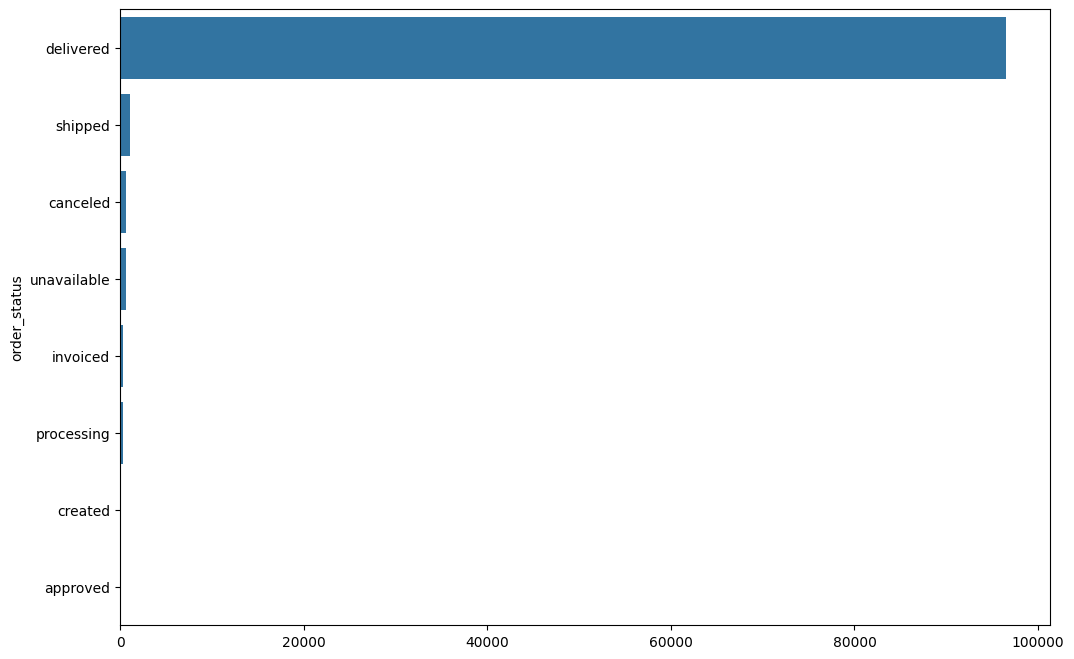

In [139]:
plt.figure(figsize=(12,8))
status_count=orders['order_status'].value_counts()
sns.barplot(x=status_count.values,y=status_count.index)

In [142]:
df_master['order_delivered_customer_date']=pd.to_datetime(df_master['order_delivered_customer_date'])
df_master['order_estimated_delivery_date']=pd.to_datetime(df_master['order_estimated_delivery_date'])
df_master['delay_days']=(df_master['order_delivered_customer_date'] - 
                   df_master['order_estimated_delivery_date'] ).dt.days

delivered_items = df_master[df_master['order_status']=="delivered"].copy()
delivered_items['is_late'] = (delivered_items['order_delivered_customer_date']
                              > delivered_items['order_estimated_delivery_date'])
delivered_orders = delivered_items.drop_duplicates('order_id')   

late_orders = delivered_orders['is_late'].sum()
print("late_orders", late_orders)
total_delivered = len(delivered_orders)
print(total_delivered)
delivered_orders_intime = total_delivered - late_orders
print(delivered_orders_intime)

late_orders 7825
96469
88644


([<matplotlib.patches.Wedge at 0x7928f3843470>,
 [Text(-1.0644774973971471, 0.2772862375508505, 'In time'),
  Text(1.064477521638277, -0.2772861444912674, 'Late')],
 [Text(-0.580624089489353, 0.15124703866410025, '91.9%'),
  Text(0.5806241027117873, -0.15124698790432764, '8.1%')])

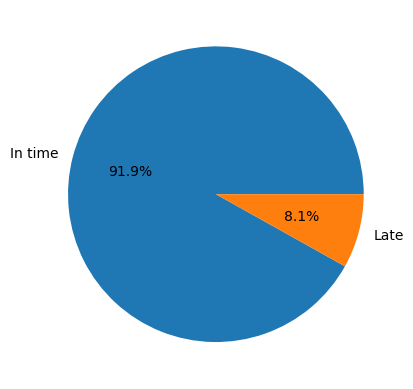

In [147]:
 plt.pie([delivered_orders_intime,late_orders], labels=["In time","Late"],autopct="%1.1f%%")

customer_state
AL    23.929471
MA    19.665272
PI    15.966387
CE    15.324472
SE    15.223881
BA    14.035627
RJ    13.473684
TO    12.773723
PA    12.367865
ES    12.230576
Name: is_late, dtype: float64


Text(0.5, 0, 'late orders (%)')

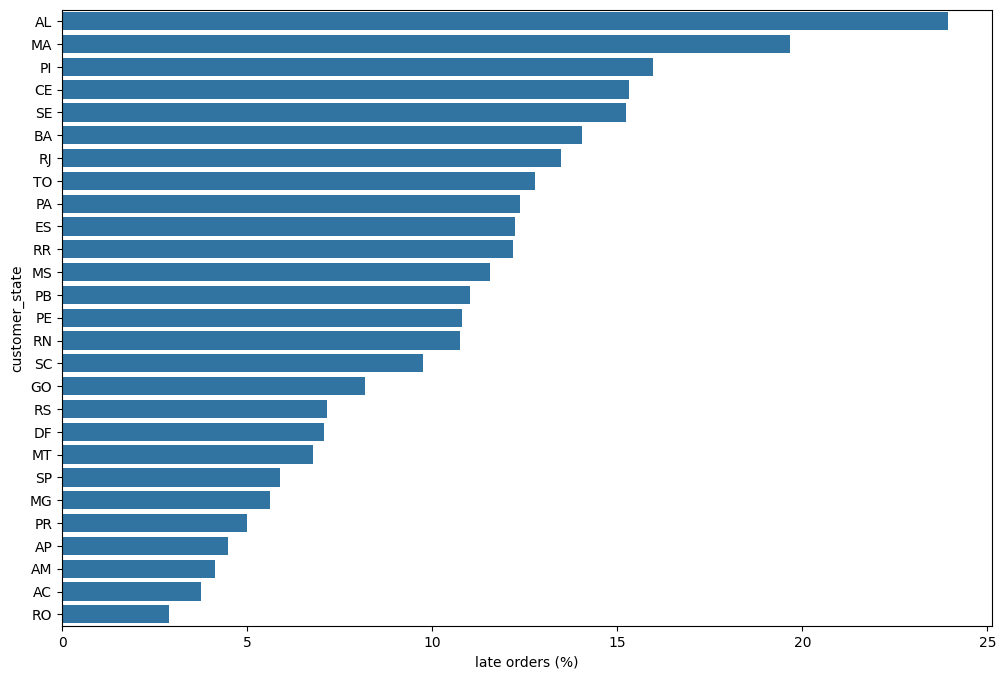

In [176]:
plt.figure(figsize=(12,8))
order_state_late = (delivered_orders.groupby("customer_state")["is_late"].mean()*100
                    ).sort_values(ascending=False)
print(order_state_late.head(10))
sns.barplot(x=order_state_late.values,y=order_state_late.index)
plt.xlabel("late orders (%)")

      product_category_name_english  late_rate  orders
5                             audio   0.129310     348
11                  books_technical   0.109375     256
48                     home_confort   0.104592     392
37                             food   0.099773     441
27                      electronics   0.098133    2517
7                              baby   0.091848    2809
58                 office_furniture   0.091707    1254
18  construction_tools_construction   0.091033     736
19        construction_tools_lights   0.090909     242
0                           UnKnown   0.090652    1412


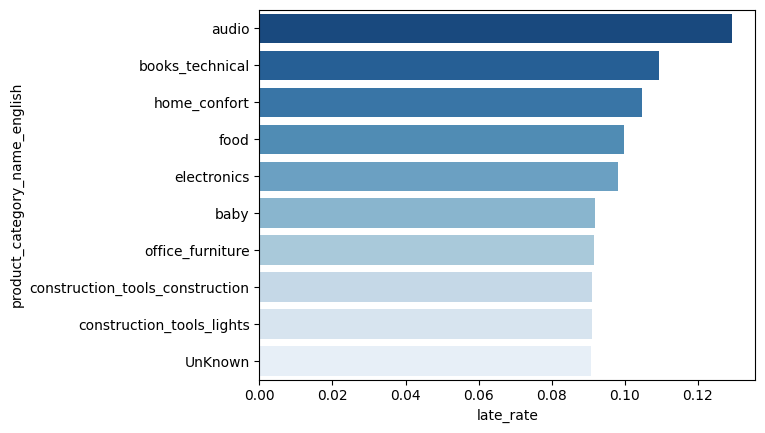

In [163]:
cat_items = delivered_items.drop_duplicates(['order_id','product_category_name_english'])
product_counts = (cat_items.groupby("product_category_name_english")["is_late"]
                  .agg(late_rate="mean", orders="size").reset_index())
product_counts = (product_counts[product_counts["orders"] >= 200]
                  .sort_values("late_rate", ascending=False).head(10))
print(product_counts)
sns.barplot(
    data=product_counts,
    x="late_rate", 
    y="product_category_name_english",
    palette="Blues_r",
    hue="product_category_name_english",
    legend=False,
)
plt.show()

In [164]:
sel_items = delivered_items.drop_duplicates(['order_id','seller_id'])
seller_performance = (sel_items.groupby("seller_id")["is_late"]
                      .agg(late_rate="mean", orders="size").reset_index())
seller_performance = seller_performance[seller_performance["orders"] >= 30]
top_sellers_delay = seller_performance.sort_values("late_rate", ascending=False).head(10)
top_sellers_delay

,seller_id,late_rate,orders
2766,ede0c03645598cdfc63ca8237acbe73d,0.348837,43
2011,ad781527c93d00d89a11eecd9dcad7c1,0.315789,38
1556,835f0f7810c76831d6c7d24c7a646d4d,0.309524,42
1000,54965bbe3e4f07ae045b90b0b8541f52,0.301370,73
478,2a1348e9addc1af5aaa619b1a3679d6b,0.270833,48
1209,66e0557ecc2b4dbea057e93f215f68d8,0.266667,30
1928,a49928bcdf77c55c6d6e05e09a9b4ca5,0.260417,96
2781,ef990a83bbea832f36ebe81376335aa8,0.255814,43
2211,beadbee30901a7f61d031b6b686095ad,0.250000,64
79,06a2c3af7b3aee5d69171b0e14f0ee87,0.231362,389


<Axes: xlabel='late_rate', ylabel='seller_id'>

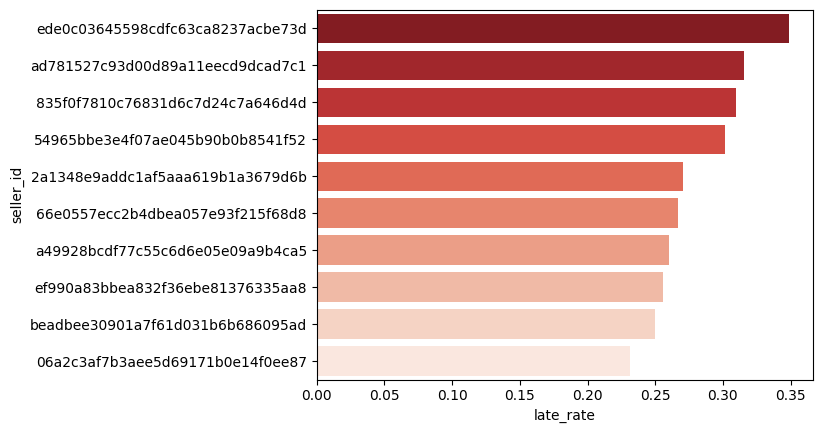

In [165]:
sns.barplot(data=top_sellers_delay, x="late_rate", y="seller_id", hue="seller_id", palette="Reds_r", legend=False)

In [166]:
top_sellers_data = delivered_items[delivered_items["seller_id"].isin(top_sellers_delay["seller_id"])]
top_categories_for_sellers=(top_sellers_data.groupby("seller_id")["product_category_name_english"].value_counts())
print(top_categories_for_sellers)

seller_id                         product_category_name_english  
06a2c3af7b3aee5d69171b0e14f0ee87  health_beauty                      402
2a1348e9addc1af5aaa619b1a3679d6b  furniture_decor                     15
                                  auto                                10
                                  health_beauty                        7
                                  computers_accessories                3
                                  consoles_games                       3
                                  fixed_telephony                      3
                                  home_confort                         3
                                  fashion_underwear_beach              2
                                  telephony                            2
                                  baby                                 1
                                  garden_tools                         1
                                  perfumery               

In [167]:
d_range = delivered_orders[delivered_orders["delay_days"].between(-10, 15)]
review_by_delay = (d_range.groupby("delay_days")["review_score"].mean().reset_index()
                   .sort_values(by="delay_days"))
print(review_by_delay)
print(delivered_orders.groupby("is_late")["review_score"].mean())   # baseline comparison

    delay_days  review_score
0        -10.0      4.332720
1         -9.0      4.292987
2         -8.0      4.257083
3         -7.0      4.256282
4         -6.0      4.246739
5         -5.0      4.195652
6         -4.0      4.146611
7         -3.0      4.120117
8         -2.0      4.125000
9         -1.0      4.157931
10         0.0      4.035547
11         1.0      3.731707
12         2.0      3.179104
13         3.0      2.683468
14         4.0      2.497706
15         5.0      2.192396
16         6.0      1.810811
17         7.0      1.917197
18         8.0      1.709091
19         9.0      1.666667
20        10.0      1.582126
21        11.0      1.725989
22        12.0      1.664516
23        13.0      1.735450
24        14.0      1.591716
25        15.0      1.709677
is_late
False    4.294292
True     2.566710
Name: review_score, dtype: float64


<Axes: xlabel='delay_days', ylabel='review_score'>

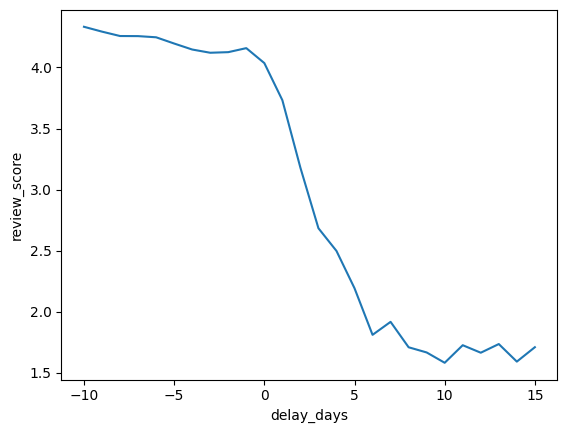

In [168]:
sns.lineplot(data=review_by_delay, x="delay_days", y="review_score")

  payment_type  late_percentage
0       boleto         8.879162
1  credit_card         7.943944
2   debit_card         7.956844
3      voucher         7.242448


/tmp/ipykernel_58/2944356850.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_delay, x="payment_type", y="late_percentage", palette="Blues_r")


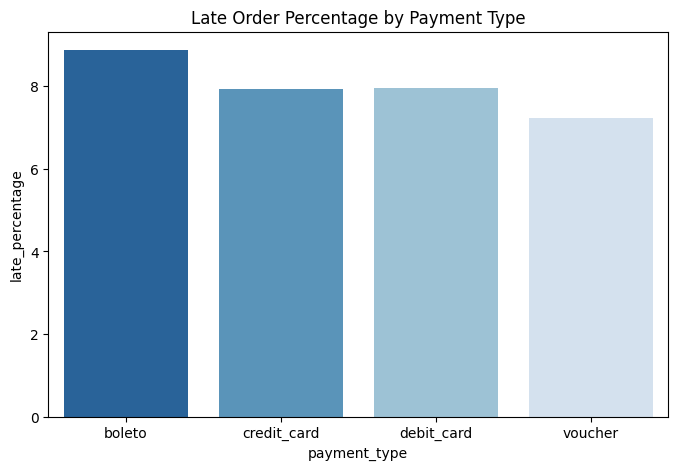

In [169]:
payment_delay = (delivered_orders.groupby("payment_type")["is_late"].mean()*100
                 ).reset_index(name="late_percentage")

print(payment_delay)

plt.figure(figsize=(8, 5))
sns.barplot(data=payment_delay, x="payment_type", y="late_percentage", palette="Blues_r")
plt.title("Late Order Percentage by Payment Type")
plt.show()

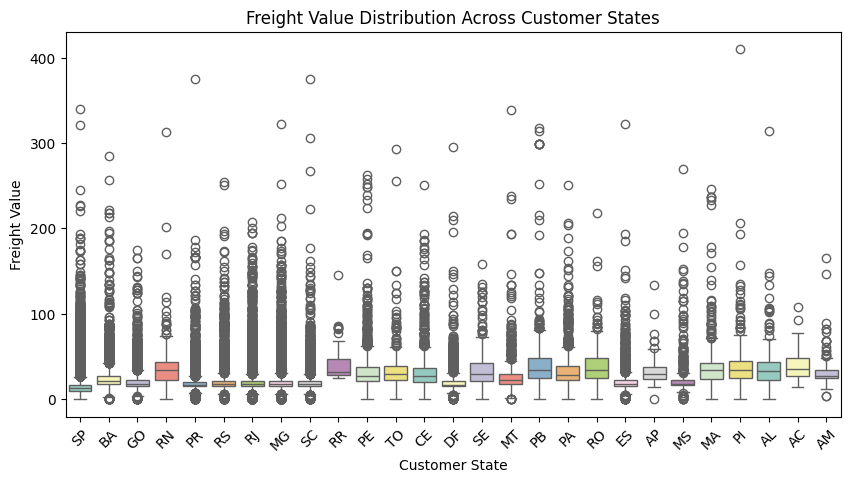

In [131]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_master, x='customer_state', y='freight_value', palette='Set3', hue='customer_state', legend=False)
plt.title('Freight Value Distribution Across Customer States')
plt.xlabel('Customer State')
plt.ylabel('Freight Value')
plt.xticks(rotation=45)
plt.show()

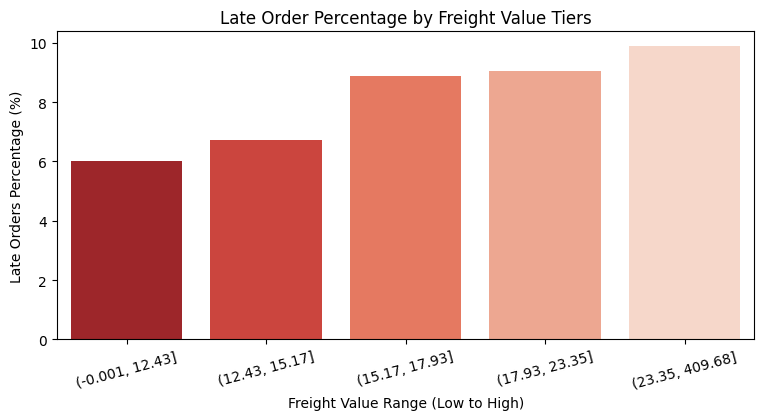

In [170]:
delivered_orders = delivered_orders.copy()
delivered_orders['freight_bins'] = pd.qcut(delivered_orders['freight_value'], q=5)
freight_delay = (delivered_orders.groupby('freight_bins', observed=True)['is_late']
                 .mean()*100).reset_index()
freight_delay['freight_bins'] = freight_delay['freight_bins'].astype(str)

plt.figure(figsize=(9, 4))
sns.barplot(data=freight_delay, x='freight_bins', y='is_late', hue='freight_bins', palette='Reds_r', legend=False)
plt.title('Late Order Percentage by Freight Value Tiers')
plt.xlabel('Freight Value Range (Low to High)')
plt.ylabel('Late Orders Percentage (%)')
plt.xticks(rotation=15)
plt.show()

customer_state
SP    38.186731
RJ    13.377898
MG    11.729526
RS     5.509560
PR     4.982424
Name: price, dtype: float64
Top 5 states share of revenue: 73.8 %


Text(0.5, 1.0, 'Revenue concentration by customer state')

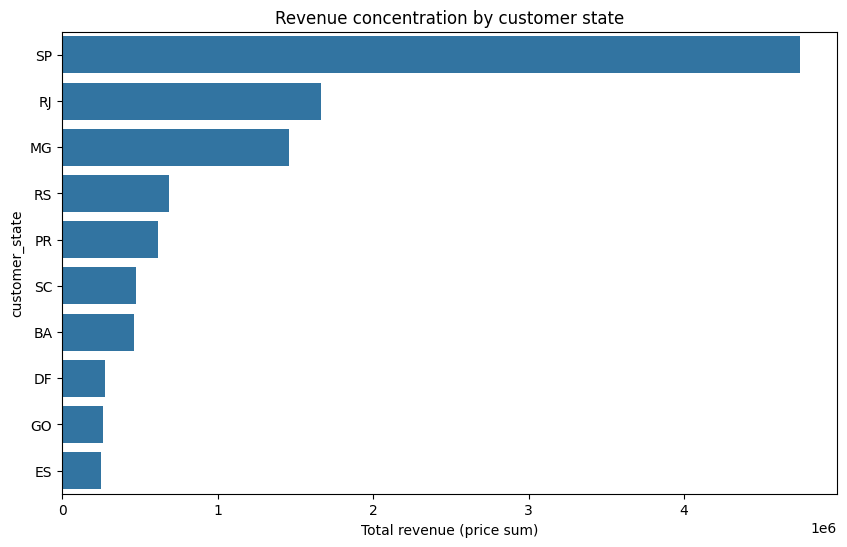

In [175]:
order_revenue = df_master.drop_duplicates('order_id')[['order_id','customer_state','price']]
state_revenue = (order_revenue.groupby('customer_state')['price'].sum()
                 .sort_values(ascending=False))
state_revenue_pct = (state_revenue / state_revenue.sum() * 100)

print(state_revenue_pct.head(5))
print("Top 5 states share of revenue:", state_revenue_pct.head(5).sum().round(1), "%")

plt.figure(figsize=(10,6))
sns.barplot(x=state_revenue.head(10).values, y=state_revenue.head(10).index)
plt.xlabel("Total revenue (price sum)")
plt.title("Revenue concentration by customer state")